# Load Data
## Condition
* normal (original SSVEP keyboard forked from [Simon's Repo](https://github.com/simonfei123/OpenVEP))
* red-green
* blue-yellow

## Data collection
* Did 5 runs for each condition
* Keyboard: 32 keys, Number of classes
* Trials per class: 2, Each key stimulus presented twice
* Channel: Number of EEG channel
* Sample: 350, (baseline_duration 0.2 + stimulus_duration 1.2) * sampling_rate 250

### 1: Libaries

In [1]:
# 1: Import 

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### 2: Basic experiment settings

In [2]:
# Number of runs per condition
N_RUNS = 5
# Number of stimulus classes
N_CLASSES = 32
# Number of trials for each class in one run
N_TRIALS_PER_CLASS = 2
# Number of EEG channels
N_CHANNELS = 8
# Number of time samples in one trial
N_SAMPLES = 350

# Sampling rate of EEG
FS = 250

# Simplify folder paths
CONDITION_DIRS = {
    "normal": Path("../data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02"),
    "redgreen": Path("../data/redgreen_cyton8_alternating-vep_32-class_1.2s/sub-01/ses-01"),
    "blueyellow": Path("../data/blueyellow_cyton8_alternating-vep_32-class_1.2s/sub-01/ses-01"),
}

# Create a folder to save notebook outputs
OUTPUT_DIR = Path("../notebook_outputs/01_load_and_qc")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### ※ Check files in ../data/

In [3]:
# Check which files exist in each condition folder

for condition_name, folder in CONDITION_DIRS.items():
    print(f"Condition: {condition_name}")
    print(f"Folder: {folder}")
    
    # Find all files, eeg-trials_2-per-class_run-1.npy
    files = sorted(folder.glob("eeg-trials_2-per-class_run-*.npy"))
    
    # Print file names
    for f in files:
        print("  ", f.name)
    
    print("-" * 40)

Condition: normal
Folder: ../data/cyton8_alternating-vep_32-class_1.2s/sub-01/ses-02
   eeg-trials_2-per-class_run-1.npy
   eeg-trials_2-per-class_run-2.npy
   eeg-trials_2-per-class_run-3.npy
   eeg-trials_2-per-class_run-4.npy
   eeg-trials_2-per-class_run-5.npy
----------------------------------------
Condition: redgreen
Folder: ../data/redgreen_cyton8_alternating-vep_32-class_1.2s/sub-01/ses-01
   eeg-trials_2-per-class_run-1.npy
   eeg-trials_2-per-class_run-2.npy
   eeg-trials_2-per-class_run-3.npy
   eeg-trials_2-per-class_run-4.npy
   eeg-trials_2-per-class_run-5.npy
----------------------------------------
Condition: blueyellow
Folder: ../data/blueyellow_cyton8_alternating-vep_32-class_1.2s/sub-01/ses-01
   eeg-trials_2-per-class_run-1.npy
   eeg-trials_2-per-class_run-2.npy
   eeg-trials_2-per-class_run-3.npy
   eeg-trials_2-per-class_run-4.npy
   eeg-trials_2-per-class_run-5.npy
----------------------------------------


### 3: Load all runs for each condition
* Load all collected data
* Conduct quality check: whether the shape is as expected, whether there are 5 runs for each condition

In [4]:
# This dictionary will store loaded data
all_raw_data = {}

# This list will store QC information for a table
qc_rows = []

# Expected flat shape before restoring order
expected_shape = (N_CLASSES * N_TRIALS_PER_CLASS, N_CHANNELS, N_SAMPLES)

for condition_name, folder in CONDITION_DIRS.items():
    # Find all eeg-trials files in this folder
    files = sorted(folder.glob("eeg-trials_2-per-class_run-*.npy"))
    
    # Create an empty dictionary for this condition
    all_raw_data[condition_name] = {}
    
    for file_path in files:
        # Extract run number from file name
        match = re.search(r"run-(\d+)\.npy$", file_path.name)
        run_number = int(match.group(1))
        
        # Load the numpy file
        eeg_trials = np.load(file_path, allow_pickle=True)
        
        # Save raw data using run number as key
        all_raw_data[condition_name][run_number] = eeg_trials
        
        # Save QC summary row
        qc_rows.append({
            "condition": condition_name,
            "run": run_number,
            "shape": str(eeg_trials.shape),
            "shape_ok": eeg_trials.shape == expected_shape
        })

# Make QC table
qc_df = pd.DataFrame(qc_rows).sort_values(["condition", "run"]).reset_index(drop=True)

qc_df

,condition,run,shape,shape_ok
0,blueyellow,1,"(64, 8, 350)",True
1,blueyellow,2,"(64, 8, 350)",True
2,blueyellow,3,"(64, 8, 350)",True
3,blueyellow,4,"(64, 8, 350)",True
4,blueyellow,5,"(64, 8, 350)",True
5,normal,1,"(64, 8, 350)",True
6,normal,2,"(64, 8, 350)",True
7,normal,3,"(64, 8, 350)",True
8,normal,4,"(64, 8, 350)",True
9,normal,5,"(64, 8, 350)",True


### ※ Check whether any runs are missing

In [5]:
for condition_name in all_raw_data:
    found_runs = sorted(all_raw_data[condition_name].keys())
    
    # Create the expected run list: [1, 2, 3, 4, 5]
    expected_runs = list(range(1, N_RUNS + 1))
    
    # Find missing runs
    missing_runs = [r for r in expected_runs if r not in found_runs]
    
    print(f"Condition: {condition_name}")
    print("Found runs:", found_runs)
    print("Missing runs:", missing_runs)
    print("-" * 40)

Condition: normal
Found runs: [1, 2, 3, 4, 5]
Missing runs: []
----------------------------------------
Condition: redgreen
Found runs: [1, 2, 3, 4, 5]
Missing runs: []
----------------------------------------
Condition: blueyellow
Found runs: [1, 2, 3, 4, 5]
Missing runs: []
----------------------------------------


### 4: Restore original trial order

In [6]:
# This dictionary will store restored trial arrays
all_restored_data = {}

for condition_name in all_raw_data:
    all_restored_data[condition_name] = {}
    
    for run_number, eeg_trials in all_raw_data[condition_name].items():
        # Create the same random permutation used during data collection
        rng = np.random.RandomState(run_number)
        shuffled_indices = rng.permutation(eeg_trials.shape[0])
        
        # Prepare an empty array with the same shape
        restored = np.empty_like(eeg_trials)
        
        # Put each trial back into its original position
        restored[shuffled_indices] = eeg_trials
        
        # Save restored data
        all_restored_data[condition_name][run_number] = restored

print("Trial order restored.")

Trial order restored.


### 5: Reshape restored data into structured format

In [7]:
# This dictionary will store reshaped data
all_reshaped_data = {}

for condition_name in all_restored_data:
    all_reshaped_data[condition_name] = {}
    
    for run_number, restored in all_restored_data[condition_name].items():
        # Reshape from (64, 8, 350) to (2, 32, 8, 350)
        reshaped = restored.reshape(N_TRIALS_PER_CLASS, N_CLASSES, N_CHANNELS, N_SAMPLES)
        
        # Save reshaped data
        all_reshaped_data[condition_name][run_number] = reshaped

# Print one example shape
for condition_name in all_reshaped_data:
    first_run = sorted(all_reshaped_data[condition_name].keys())[0]
    print(condition_name, first_run, all_reshaped_data[condition_name][first_run].shape)
    break

normal 1 (2, 32, 8, 350)


### 6: Compute one simple QC value: mean RMS for each run
* Check if there are abnormal runs
* Use Root Mean Square to ignore +/- of amplitude

In [8]:
rms_rows = []

for condition_name in all_reshaped_data:
    for run_number, run_data in all_reshaped_data[condition_name].items():
        # Flatten (2, 32, 8, 350) into (64, 8, 350)
        x = run_data.reshape(-1, N_CHANNELS, N_SAMPLES)
        
        # Compute RMS over time for each trial and channel
        # x**2 makes all values positive
        # np.mean(..., axis=-1) averages across time
        # np.sqrt(...) brings the scale back
        rms = np.sqrt(np.mean(x**2, axis=-1))
        
        # Take the average across all trials and channels
        mean_rms = rms.mean()
        
        rms_rows.append({
            "condition": condition_name,
            "run": run_number,
            "mean_rms": mean_rms
        })

rms_df = pd.DataFrame(rms_rows).sort_values(["condition", "run"]).reset_index(drop=True)

rms_df

,condition,run,mean_rms
0,blueyellow,1,10.243837
1,blueyellow,2,9.998041
2,blueyellow,3,9.968203
3,blueyellow,4,8.236003
4,blueyellow,5,9.549776
5,normal,1,8.729539
6,normal,2,8.960164
7,normal,3,7.779467
8,normal,4,8.112012
9,normal,5,8.176320


### 7: Visualize mean_rms with a bar plot

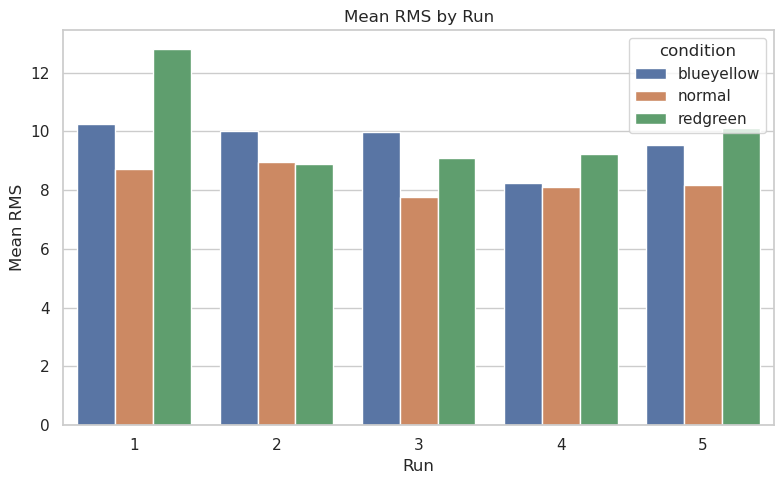

In [9]:
plt.figure(figsize=(8, 5))

# Draw a bar plot
sns.barplot(data=rms_df, x="run", y="mean_rms", hue="condition")

plt.title("Mean RMS by Run")
plt.xlabel("Run")
plt.ylabel("Mean RMS")
plt.tight_layout()
plt.show()

### 8: Create a table of avg waveform for each condition

In [10]:
trial_rows = []

for condition_name in all_reshaped_data:
    for run_number, run_data in all_reshaped_data[condition_name].items():
        # run_data shape is (2, 32, 8, 350)
        
        for repeat_idx in range(N_TRIALS_PER_CLASS):
            for class_idx in range(N_CLASSES):
                # Extract one trial with shape (8, 350)
                trial = run_data[repeat_idx, class_idx]
                
                trial_rows.append({
                    "condition": condition_name,
                    "run": run_number,
                    "trial_repeat": repeat_idx,
                    "class_id": class_idx,
                    "trial_data": trial
                })

trial_df = pd.DataFrame(trial_rows)

trial_df.head()

,condition,run,trial_repeat,class_id,trial_data
0,normal,1,0,0,"[[-0.2434869664387796, 1.5828485355098065, -0...."
1,normal,1,0,1,"[[3.167760225978882, 1.2653200419421993, 0.076..."
2,normal,1,0,2,"[[-6.807101365746141, -9.434862271641649, -11...."
3,normal,1,0,3,"[[4.4204757593850665, 7.617001642077252, 5.238..."
4,normal,1,0,4,"[[10.330956073026055, 8.63652817570136, 6.8965..."


### 9: Visualize the grand-average waveform for each condition

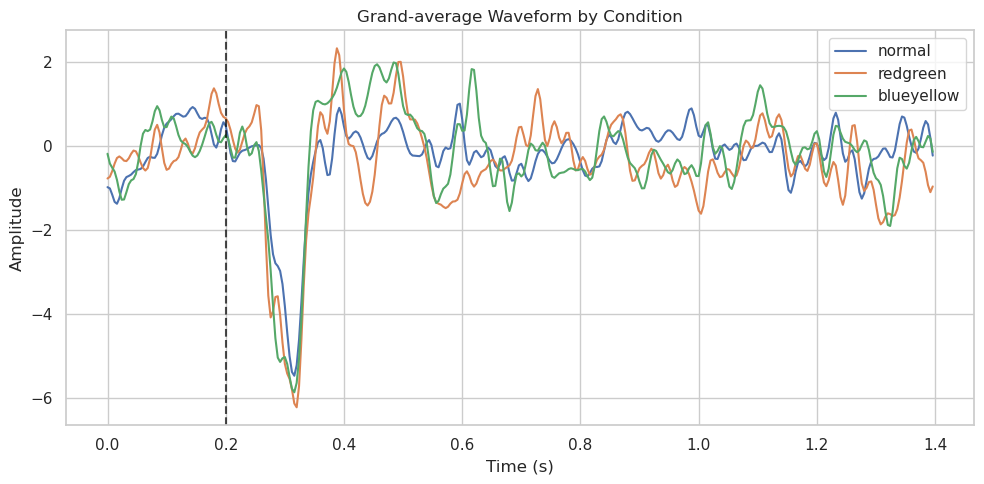

In [11]:
time = np.arange(N_SAMPLES) / FS

plt.figure(figsize=(10, 5))

for condition_name in trial_df["condition"].unique():
    # Select only trials from one condition
    condition_trials = trial_df.loc[trial_df["condition"] == condition_name, "trial_data"].values
    
    # Convert list of arrays into one numpy array
    # Shape becomes (n_trials, 8, 350)
    condition_trials = np.stack(condition_trials, axis=0)
    
    # Average across trials and channels
    # Result shape becomes (350,)
    mean_wave = condition_trials.mean(axis=(0, 1))
    
    plt.plot(time, mean_wave, label=condition_name)

# Draw a vertical line at 0.2 s
# This is the baseline/stimulus boundary in your saved trial data
plt.axvline(0.2, linestyle="--", color="black", alpha=0.7)

plt.title("Grand-average Waveform by Condition")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()